In [1]:
#IMPORTING REQUIRED LIBRARIES
import os
import glob
import numpy as np
import matplotlib.pyplot as plt 
import tensorflow as tf
from tensorflow.keras.preprocessing import image  # type: ignore

## PREDICTION FOR POTATO CLASS

In [2]:
# 1. LOADING OUR TRAINED MODEL OF PLANT : POTATO HERE
model_path = 'C:/Users/sanch/Documents/Git_hub/Streamlit-KrishiNetra/04_Models/potato_model_18.keras'

if not os.path.exists(model_path):
    print(f"Error: Model file not found at {model_path}")
else:
    model = tf.keras.models.load_model(model_path)
    print("\nModel loaded successfully.\n")

# Define Class Names
class_names = ["Potato_Early Blight", "Potato_Late Blight", "Healthy"]


Model loaded successfully.



In [3]:
def predict_and_plot_batch(img_paths, target_size=(150, 150)):
    """
    Loops through 4-6 images, predicts their classes, and displays the results in a matplotlib matrix grid.
    """
    num_images = len(img_paths)
    if num_images == 0:
        print("No images found for prediction!")
        return

    # Calculate dynamic grid size (Maximum 3 columns per row)
    cols = min(3, num_images)
    rows = (num_images + cols - 1) // cols

    # Set dynamic plot size based on the matrix layout
    plt.figure(figsize=(5 * cols, 5 * rows))

    print(f"Processing {num_images} images into a {rows}x{cols} grid layout...")

    for i, img_path in enumerate(img_paths):
        if not os.path.exists(img_path):
            print(f"File missing: {img_path}")
            continue

        # 2. IMAGE PREPROCESSING (150x150 conversion and scaling)
        img = image.load_img(img_path, target_size=target_size)
        img_array = image.img_to_array(img)
        img_array = img_array / 255.0  # Normalization
        img_array = np.expand_dims(img_array, axis=0)  # Expand batch dimension

        # 3. MODEL PREDICTION
        prediction = model.predict(img_array, verbose=0)  # verbose=0 hides the prediction progress bar
        score = prediction[0]
        
        result_index = np.argmax(score)
        result_label = class_names[result_index]
        confidence = 100 * np.max(score)

        # 4. PLOTTING SUBPLOT MATRIX
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis("on")  # Enable pixel border grids

        # Label styling: Green text for healthy leaves, red text for diseased leaves
        text_color = "green" if "healthy" in result_label.lower() else "blue"
        
        # Clean label strings (replacing ___ and _ with hyphens/spaces)
        clean_label = result_label.replace("___", "-").replace("_", " ")

        plt.title(
            f"Actual File name: {os.path.basename(img_path)}\n"
            f"AI Prediction: {clean_label}\n"
            f"Confidence: {confidence:.2f}%",
            fontsize=10,
            color=text_color,
            weight="bold"
        )

    plt.tight_layout()
    plt.show()

Processing 12 images into a 4x3 grid layout...


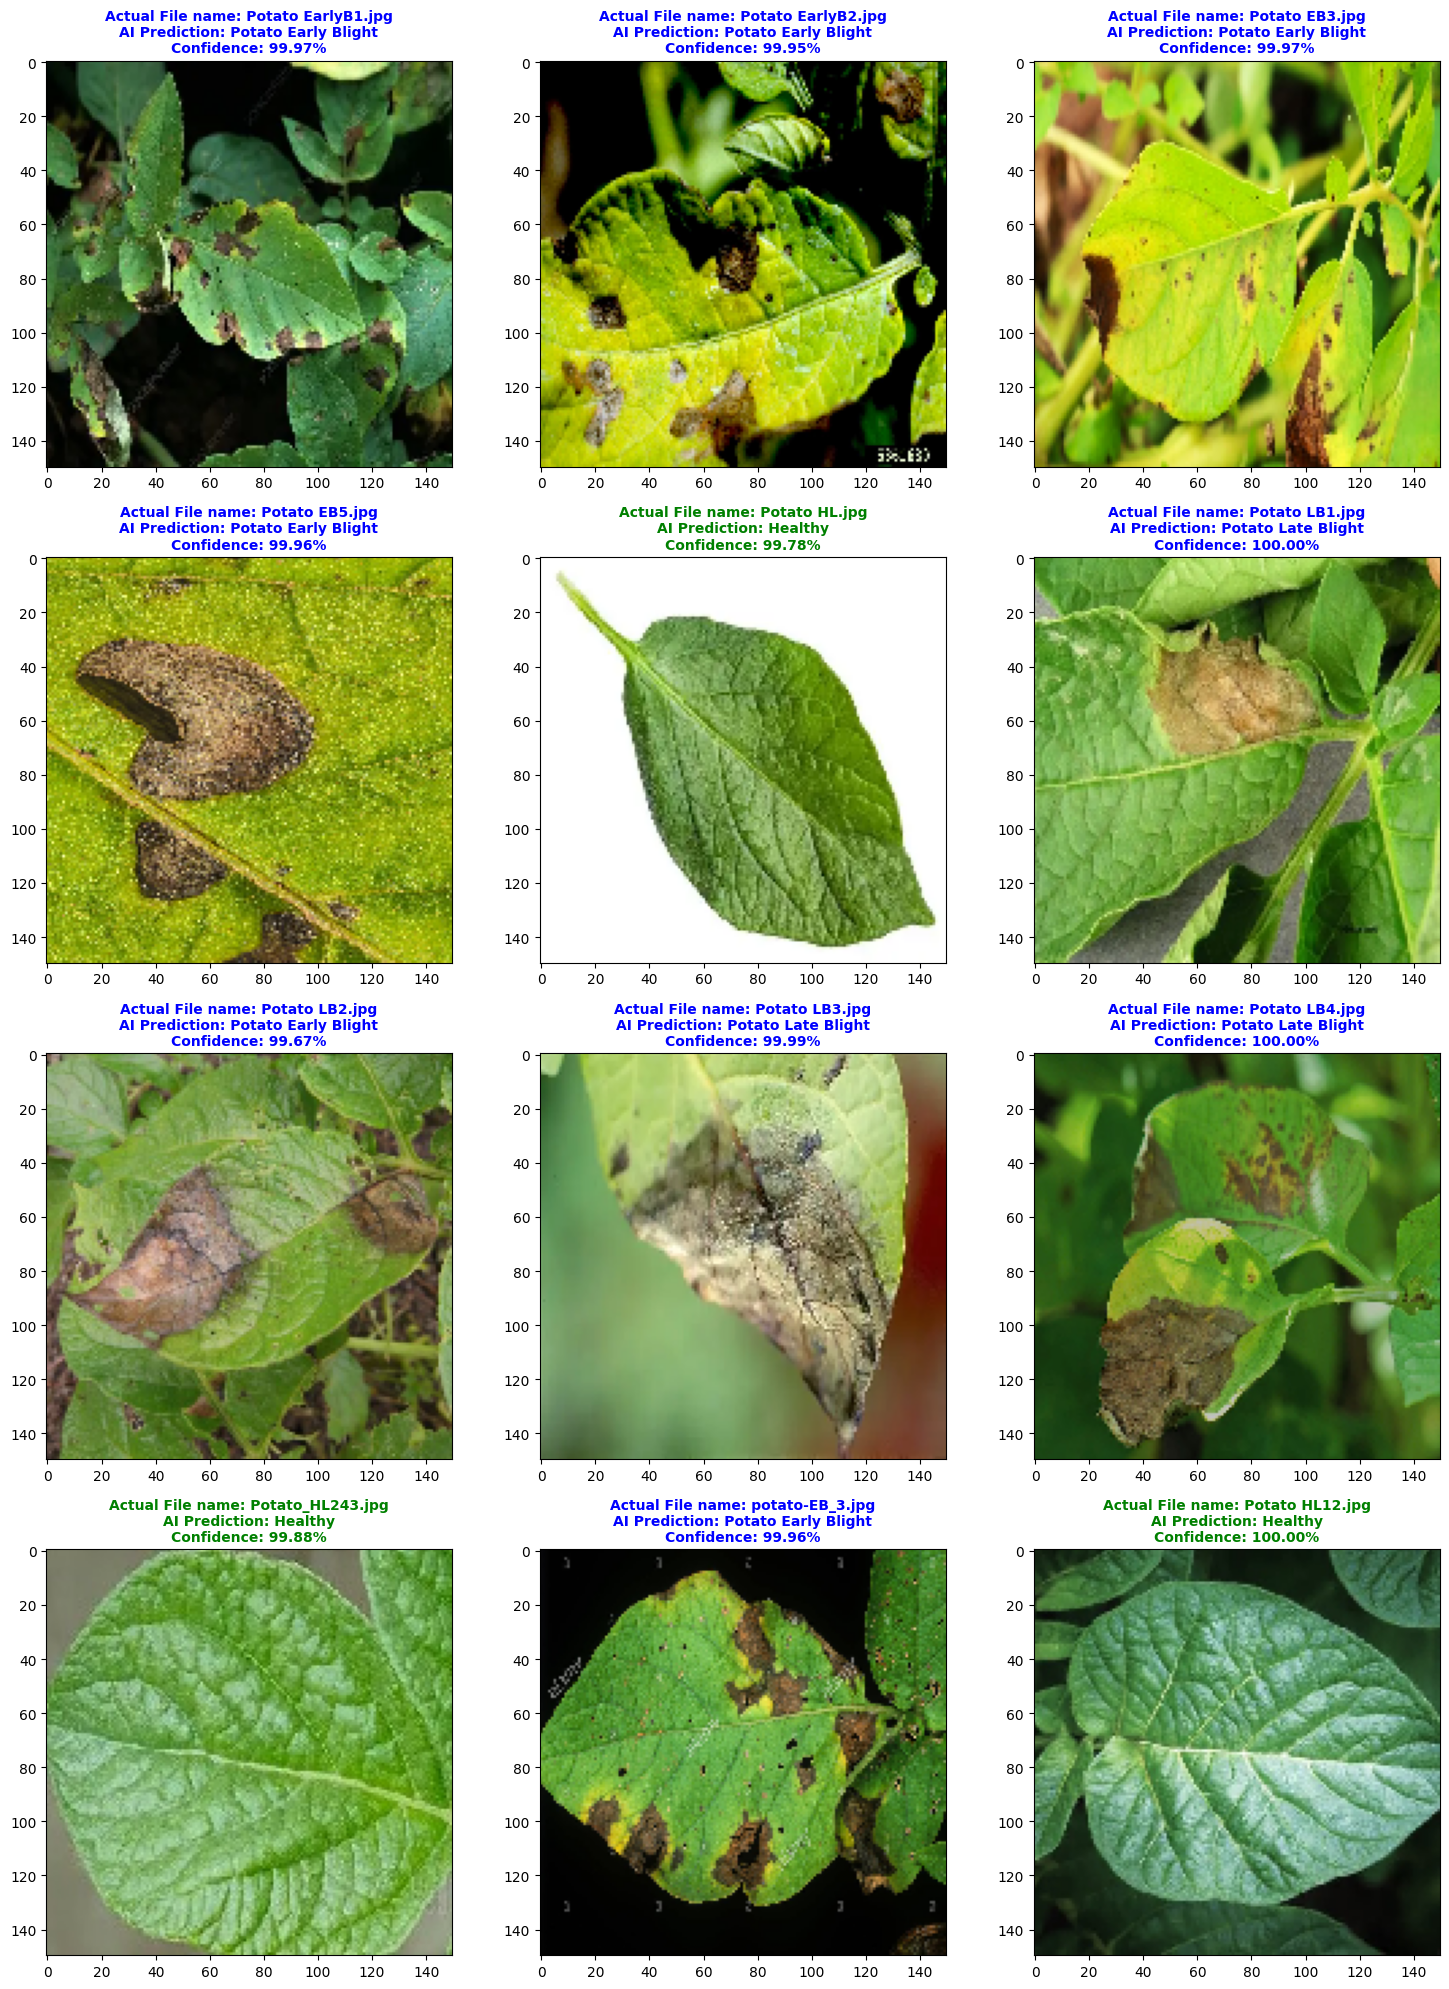

In [5]:
# Cell 4: Manually specifying specific images for potato prediction

# Manually adding the paths of the specific images you want to evaluate:
my_test_images = [
    "C:/Users/sanch/Documents/Git_hub/Streamlit-KrishiNetra/03_Notebooks/02_Production_Final/Prediction_File_Images/Potato Predict/Potato EarlyB1.jpg",
    "C:/Users/sanch/Documents/Git_hub/Streamlit-KrishiNetra/03_Notebooks/02_Production_Final/Prediction_File_Images/Potato Predict/Potato EarlyB2.jpg",
    "C:/Users/sanch/Documents/Git_hub/Streamlit-KrishiNetra/03_Notebooks/02_Production_Final/Prediction_File_Images/Potato Predict/Potato EB3.jpg",

    "C:/Users/sanch/Documents/Git_hub/Streamlit-KrishiNetra/03_Notebooks/02_Production_Final/Prediction_File_Images/Potato Predict/Potato EB5.jpg",
    "C:/Users/sanch/Documents/Git_hub/Streamlit-KrishiNetra/03_Notebooks/02_Production_Final/Prediction_File_Images/Potato Predict/Potato HL.jpg",
    "C:/Users/sanch/Documents/Git_hub/Streamlit-KrishiNetra/03_Notebooks/02_Production_Final/Prediction_File_Images/Potato Predict/Potato LB1.jpg",

    "C:/Users/sanch/Documents/Git_hub/Streamlit-KrishiNetra/03_Notebooks/02_Production_Final/Prediction_File_Images/Potato Predict/Potato LB2.jpg",
    "C:/Users/sanch/Documents/Git_hub/Streamlit-KrishiNetra/03_Notebooks/02_Production_Final/Prediction_File_Images/Potato Predict/Potato LB3.jpg",
    "C:/Users/sanch/Documents/Git_hub/Streamlit-KrishiNetra/03_Notebooks/02_Production_Final/Prediction_File_Images/Potato Predict/Potato LB4.jpg",

    "C:/Users/sanch/Documents/Git_hub/Streamlit-KrishiNetra/03_Notebooks/02_Production_Final/Prediction_File_Images/Potato Predict/Potato_HL243.jpg",
    "C:/Users/sanch/Documents/Git_hub/Streamlit-KrishiNetra/03_Notebooks/02_Production_Final/Prediction_File_Images/Potato Predict/potato-EB_3.jpg",
    "C:/Users/sanch/Documents/Git_hub/Streamlit-KrishiNetra/03_Notebooks/02_Production_Final/Prediction_File_Images/Potato Predict/Potato HL12.jpg"
]
    
   

# Trigger the grid visualizer pipeline with the manual list
predict_and_plot_batch(my_test_images)